# Audit the historical monthly climatology

This notebook independently verifies that the generated 1971–2000 monthly-mean files were calculated correctly from the original monthly time series.

It performs three distinct checks:

1. **Raw-series integrity:** every grid-cell block must contain the exact ordered sequence `1971-01 … 2000-12`, with no missing, duplicated, or repeated coordinate blocks.
2. **Transformation correctness:** monthly means are recomputed independently from the raw files in chunks and compared with the generated climatology values at six-decimal output precision.
3. **External reconciliation:** the mean of the 12 monthly climatology values is compared with the supplied historical and future annual-mean files.

The third check is evidence of consistency, not complete provenance: without the raw future time series, this notebook cannot prove the exact upstream procedure used to create the supplied future monthly climatology.

## 1 · Configuration

In [1]:
from pathlib import Path
import gc
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 11,
    "axes.titlesize": 12,
})

DATA_DIR_CANDIDATES = [
    Path("/nird/datapeak/NS9188K/adelez/BRL-FRST-XPSN/data/edit-surfdata/LPJ-GUESS"),
    Path("~/BOREAL-FOREST-EXPANSION/data/edit-surfdata/LPJ-GUESS").expanduser(),
]
DATA_DIR = next(
    (path for path in DATA_DIR_CANDIDATES if (path / "mfpc_pft_avg_1971_2000.out").exists()),
    DATA_DIR_CANDIDATES[-1],
)

OUTPUT_DIR = Path("01-monthly-mean-verification")
FIGURE_DIR = Path("01-monthly-mean-verification")
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

RAW_HISTORICAL = {
    "FPC": DATA_DIR / "mfpc_pft_avg_1971_2000.out",
    "LAI": DATA_DIR / "mlai_pft_avg_1971_2000.out",
}
GENERATED_HISTORICAL = {
    "FPC": DATA_DIR / "mfpc_pft_avg_1971_2000_monthly_mean.out",
    "LAI": DATA_DIR / "mlai_pft_avg_1971_2000_monthly_mean.out",
}
ANNUAL_HISTORICAL = {
    "FPC": DATA_DIR / "fpc1971to2000.txt",
    "LAI": DATA_DIR / "lai1971to2000.txt",
}
MONTHLY_FUTURE = {
    "FPC": DATA_DIR / "mfpc_pft_avg_2070_2100_monthly_mean.out",
    "LAI": DATA_DIR / "mlai_pft_avg_2070_2100_monthly_mean.out",
}

future_lai_candidates = [
    DATA_DIR / "GFDL-ESM4_SPP585_lai2071to2100.txt",
    DATA_DIR / "GFDL-ESM4_SSP585_lai2071to2100.txt",
]
ANNUAL_FUTURE = {
    "FPC": DATA_DIR / "GFDL-ESM4_SSP585_fpc2071to2100.txt",
    "LAI": next((path for path in future_lai_candidates if path.exists()), future_lai_candidates[0]),
}

EXPECTED_YEARS = range(1971, 2001)
CHUNKSIZE = 250_000
GENERATED_TOLERANCE = 5.1e-7
ANNUAL_TOLERANCE = 1e-3
VERIFY_VARIABLES = ["FPC", "LAI"]

print("Data directory:", DATA_DIR)
for collection in [RAW_HISTORICAL, GENERATED_HISTORICAL, ANNUAL_HISTORICAL, MONTHLY_FUTURE, ANNUAL_FUTURE]:
    for label, path in collection.items():
        print(f"{label:3s}  {path.name:55s}  {'found' if path.exists() else 'MISSING'}")

print(
    "NOTE: the future monthly filenames say 2070–2100, while the annual filenames say 2071–2100. "
    "Use the reconciliation results as a diagnostic and confirm the intended period with the producer."
)

Data directory: /nird/datapeak/NS9188K/adelez/BRL-FRST-XPSN/data/edit-surfdata/LPJ-GUESS
FPC  mfpc_pft_avg_1971_2000.out                               found
LAI  mlai_pft_avg_1971_2000.out                               found
FPC  mfpc_pft_avg_1971_2000_monthly_mean.out                  found
LAI  mlai_pft_avg_1971_2000_monthly_mean.out                  found
FPC  fpc1971to2000.txt                                        found
LAI  lai1971to2000.txt                                        found
FPC  mfpc_pft_avg_2070_2100_monthly_mean.out                  found
LAI  mlai_pft_avg_2070_2100_monthly_mean.out                  found
FPC  GFDL-ESM4_SSP585_fpc2071to2100.txt                       found
LAI  GFDL-ESM4_SPP585_lai2071to2100.txt                       found
NOTE: the future monthly filenames say 2070–2100, while the annual filenames say 2071–2100. Use the reconciliation results as a diagnostic and confirm the intended period with the producer.


## 2 · Exact raw-series sequence validation

This low-memory pass reads only `Lon`, `Lat`, `Year`, and `Month`. It verifies the exact sequence for every coordinate rather than relying only on total row counts. Because the raw files are approximately 1.6 GB each, this cell may take several minutes.

In [8]:
def validate_raw_sequence(path, first_year=1971, last_year=2000, progress_every=1_000_000):
    started = time.time()
    seen_coordinates = set()
    current_coordinate = None
    expected_year = first_year
    expected_month = 1
    data_rows = 0
    repeated_headers = 0

    with path.open() as stream:
        header = stream.readline().split()
        if header[:4] != ["Lon", "Lat", "Year", "Month"]:
            raise ValueError(f"{path}: unexpected first columns {header[:4]}")

        for line_number, line in enumerate(stream, start=2):
            fields = line.split()
            if not fields:
                continue
            if fields[0] == "Lon":
                repeated_headers += 1
                continue
            if len(fields) != len(header):
                raise ValueError(f"{path}: line {line_number} has {len(fields)} fields; expected {len(header)}")

            lon, lat = float(fields[0]), float(fields[1])
            year, month = int(fields[2]), int(fields[3])
            coordinate = (lon, lat)

            if coordinate != current_coordinate:
                if current_coordinate is not None and (expected_year != last_year + 1 or expected_month != 1):
                    raise ValueError(f"{path}: incomplete sequence for {current_coordinate}")
                if coordinate in seen_coordinates:
                    raise ValueError(f"{path}: non-contiguous repeated coordinate block {coordinate}")
                seen_coordinates.add(coordinate)
                current_coordinate = coordinate
                expected_year, expected_month = first_year, 1

            if (year, month) != (expected_year, expected_month):
                raise ValueError(
                    f"{path}: line {line_number}, coordinate {coordinate}: expected "
                    f"{expected_year}-{expected_month:02d}, found {year}-{month:02d}"
                )

            expected_month += 1
            if expected_month == 13:
                expected_month = 1
                expected_year += 1

            data_rows += 1
            if data_rows % progress_every == 0:
                print(f"  {path.name}: checked {data_rows:,} rows")

    if current_coordinate is None:
        raise ValueError(f"{path}: no data rows")
    if expected_year != last_year + 1 or expected_month != 1:
        raise ValueError(f"{path}: incomplete final sequence for {current_coordinate}")

    expected_rows = len(seen_coordinates) * (last_year - first_year + 1) * 12
    if data_rows != expected_rows:
        raise AssertionError(f"{path}: {data_rows:,} rows; expected {expected_rows:,}")

    return {
        "file": path.name,
        "grid cells": len(seen_coordinates),
        "data rows": data_rows,
        "first year": first_year,
        "last year": last_year,
        "months per year": 12,
        "repeated headers": repeated_headers,
        "exact sequence valid": True,
        "elapsed seconds": time.time() - started,
    }


sequence_reports = []
for variable in VERIFY_VARIABLES:
    path = RAW_HISTORICAL[variable]
    if path.exists():
        print(f"Validating {variable}: {path.name}")
        sequence_reports.append({"variable": variable, **validate_raw_sequence(path)})
    else:
        print(f"Skipping {variable}; missing: {path}")

sequence_report = pd.DataFrame(sequence_reports).set_index("variable")
#display(sequence_report.round({"elapsed seconds": 1}))

Validating FPC: mfpc_pft_avg_1971_2000.out
  mfpc_pft_avg_1971_2000.out: checked 1,000,000 rows
  mfpc_pft_avg_1971_2000.out: checked 2,000,000 rows
  mfpc_pft_avg_1971_2000.out: checked 3,000,000 rows
  mfpc_pft_avg_1971_2000.out: checked 4,000,000 rows
  mfpc_pft_avg_1971_2000.out: checked 5,000,000 rows
  mfpc_pft_avg_1971_2000.out: checked 6,000,000 rows
Validating LAI: mlai_pft_avg_1971_2000.out
  mlai_pft_avg_1971_2000.out: checked 1,000,000 rows
  mlai_pft_avg_1971_2000.out: checked 2,000,000 rows
  mlai_pft_avg_1971_2000.out: checked 3,000,000 rows
  mlai_pft_avg_1971_2000.out: checked 4,000,000 rows
  mlai_pft_avg_1971_2000.out: checked 5,000,000 rows
  mlai_pft_avg_1971_2000.out: checked 6,000,000 rows


## 3 · Independently recompute the monthly climatology

This second pass uses chunked `pandas` aggregation. It does not use the Bash output as an input to the calculation. The generated file is loaded only after the independent recomputation is complete.

In [3]:
def read_numeric_table(path, key_columns):
    frame = pd.read_csv(path, sep=r"\s+", dtype=str, low_memory=False)
    frame = frame.loc[~frame[key_columns[0]].astype(str).eq(key_columns[0])].copy()
    for column in frame.columns:
        frame[column] = pd.to_numeric(frame[column], errors="raise")
    return frame


def recompute_monthly_climatology(raw_path, chunksize=CHUNKSIZE):
    columns = pd.read_csv(raw_path, sep=r"\s+", nrows=0).columns.tolist()
    keys = ["Lon", "Lat", "Month"]
    value_columns = [column for column in columns if column not in {"Lon", "Lat", "Year", "Month"}]
    dtype = {"Lon": "float64", "Lat": "float64", "Year": "int16", "Month": "int8"}
    dtype.update({column: "float64" for column in value_columns})

    accumulated_sums = None
    accumulated_counts = None
    row_count = 0
    started = time.time()

    reader = pd.read_csv(raw_path, sep=r"\s+", dtype=dtype, chunksize=chunksize)
    for chunk_number, chunk in enumerate(reader, start=1):
        partial_sums = chunk.groupby(keys, sort=False)[value_columns].sum()
        partial_counts = chunk.groupby(keys, sort=False).size()
        accumulated_sums = partial_sums if accumulated_sums is None else accumulated_sums.add(partial_sums, fill_value=0)
        accumulated_counts = partial_counts if accumulated_counts is None else accumulated_counts.add(partial_counts, fill_value=0)
        row_count += len(chunk)
        print(f"  chunk {chunk_number:02d}: {row_count:,} rows processed")

    if not accumulated_counts.eq(len(EXPECTED_YEARS)).all():
        bad = accumulated_counts.loc[~accumulated_counts.eq(len(EXPECTED_YEARS))]
        raise ValueError(f"{raw_path}: {len(bad)} grid-cell/month groups do not contain 30 rows")

    climatology = accumulated_sums.div(accumulated_counts, axis=0).sort_index()
    return climatology, {
        "raw rows": row_count,
        "grid-cell/month groups": len(climatology),
        "minimum records per mean": int(accumulated_counts.min()),
        "maximum records per mean": int(accumulated_counts.max()),
        "elapsed seconds": time.time() - started,
    }


def compare_recomputed_with_generated(raw_path, generated_path, tolerance=GENERATED_TOLERANCE):
    recomputed, report = recompute_monthly_climatology(raw_path)
    generated = read_numeric_table(generated_path, ["Lon", "Lat", "Month"])
    generated = generated.set_index(["Lon", "Lat", "Month"]).sort_index()

    missing_generated = recomputed.index.difference(generated.index)
    unexpected_generated = generated.index.difference(recomputed.index)
    if len(missing_generated) or len(unexpected_generated):
        raise ValueError(
            f"Coordinate/month mismatch: missing generated={len(missing_generated)}, "
            f"unexpected generated={len(unexpected_generated)}"
        )

    columns = [column for column in recomputed.columns if column in generated.columns]
    residual = generated[columns] - recomputed[columns]
    summary = pd.DataFrame({
        "mean residual": residual.mean(),
        "mean absolute residual": residual.abs().mean(),
        "maximum absolute residual": residual.abs().max(),
        "values outside tolerance": residual.abs().gt(tolerance).sum(),
    })

    worst = (
        residual.abs().stack().rename("absolute residual")
        .nlargest(20).reset_index().rename(columns={"level_3": "field"})
    )
    report.update({
        "generated rows": len(generated),
        "compared fields": len(columns),
        "maximum absolute residual": float(residual.abs().to_numpy().max()),
        "values outside tolerance": int(residual.abs().gt(tolerance).to_numpy().sum()),
        "tolerance": tolerance,
        "exact transformation check passed": bool((residual.abs() <= tolerance).to_numpy().all()),
    })
    del recomputed, generated, residual
    gc.collect()
    return summary, worst, report

In [4]:
transformation_summaries = []
transformation_reports = []
worst_residuals = []

for variable in VERIFY_VARIABLES:
    raw_path = RAW_HISTORICAL[variable]
    generated_path = GENERATED_HISTORICAL[variable]
    if not (raw_path.exists() and generated_path.exists()):
        print(f"Skipping {variable}; raw or generated file is missing.")
        continue

    print(f"Recomputing and comparing {variable}")
    summary, worst, report = compare_recomputed_with_generated(raw_path, generated_path)
    summary.insert(0, "variable", variable)
    worst.insert(0, "variable", variable)
    transformation_summaries.append(summary.reset_index(names="field"))
    worst_residuals.append(worst)
    transformation_reports.append({"variable": variable, **report})

transformation_summary = pd.concat(transformation_summaries, ignore_index=True)
transformation_report = pd.DataFrame(transformation_reports).set_index("variable")
worst_residuals = pd.concat(worst_residuals, ignore_index=True)

display(transformation_report.round(9))
display(transformation_summary.set_index(["variable", "field"]).round(9))
display(worst_residuals.head(20))

transformation_report.to_csv(OUTPUT_DIR / "raw_to_generated_verification.csv")
transformation_summary.to_csv(OUTPUT_DIR / "raw_to_generated_residuals_by_field.csv", index=False)
worst_residuals.to_csv(OUTPUT_DIR / "raw_to_generated_largest_residuals.csv", index=False)

Recomputing and comparing FPC
  chunk 01: 250,000 rows processed
  chunk 02: 500,000 rows processed
  chunk 03: 750,000 rows processed
  chunk 04: 1,000,000 rows processed
  chunk 05: 1,250,000 rows processed
  chunk 06: 1,500,000 rows processed
  chunk 07: 1,750,000 rows processed
  chunk 08: 2,000,000 rows processed
  chunk 09: 2,250,000 rows processed
  chunk 10: 2,500,000 rows processed
  chunk 11: 2,750,000 rows processed
  chunk 12: 3,000,000 rows processed
  chunk 13: 3,250,000 rows processed
  chunk 14: 3,500,000 rows processed
  chunk 15: 3,750,000 rows processed
  chunk 16: 4,000,000 rows processed
  chunk 17: 4,250,000 rows processed
  chunk 18: 4,500,000 rows processed
  chunk 19: 4,750,000 rows processed
  chunk 20: 5,000,000 rows processed
  chunk 21: 5,250,000 rows processed
  chunk 22: 5,500,000 rows processed
  chunk 23: 5,750,000 rows processed
  chunk 24: 6,000,000 rows processed
  chunk 25: 6,017,040 rows processed
Recomputing and comparing LAI
  chunk 01: 250,000 r

,raw rows,grid-cell/month groups,minimum records per mean,maximum records per mean,elapsed seconds,generated rows,compared fields,maximum absolute residual,values outside tolerance,tolerance,exact transformation check passed
variable,,,,,,,,,,,
FPC,6017040,200568,30,30,18.078928,200568,24,3.330000e-07,0,5.100000e-07,True
LAI,6017040,200568,30,30,17.782514,200568,24,3.330000e-07,0,5.100000e-07,True


mean residual  mean absolute residual  \
variable field                                            
FPC      BNE      -1.000000e-09            1.110000e-07   
         BINE     -3.000000e-09            1.100000e-07   
         BNS      -1.000000e-09            3.500000e-08   
         TeNE      0.000000e+00            0.000000e+00   
         TeBE      0.000000e+00            0.000000e+00   
         IBS      -1.000000e-09            6.000000e-08   
         TeBS     -0.000000e+00            4.000000e-09   
         C3G      -1.000000e-09            8.000000e-08   
         HSE       1.000000e-09            2.400000e-08   
         HSS      -1.000000e-09            7.400000e-08   
         LSE      -3.000000e-09            2.100000e-07   
         LSS      -3.000000e-09            1.050000e-07   
         GRT      -0.000000e+00            3.800000e-08   
         EPDS     -3.000000e-09            6.800000e-08   
         SPDS     -1.000000e-09            3.100000e-08   
         CLM      -0.000000e+00            0.000000e+00   
         pLSE     -0.000000e+00            1.000000e-08   
         pLSS     -1.000000e-09            4.000000e-09   
         pCLM      0.000000e+00            0.000000e+00   
         WetGRS   -0.000000e+00            4.600000e-08   
         pmoss    -0.000000e+00            4.900000e-08   
         C3G_wet   0.000000e+00            0.000000e+00   
         C4G_wet   0.000000e+00            0.000000e+00   
         Total    -1.000000e-09            2.200000e-07   
LAI      BNE      -1.000000e-09            1.120000e-07   
         BINE     -2.000000e-09            1.120000e-07   
         BNS      -1.000000e-09            3.600000e-08   
         TeNE      0.000000e+00            0.000000e+00   
         TeBE      0.000000e+00            0.000000e+00   
         IBS      -1.000000e-09            6.100000e-08   
         TeBS      0.000000e+00            4.000000e-09   
         C3G      -0.000000e+00            8.100000e-08   
         HSE      -1.000000e-09            2.400000e-08   
         HSS      -1.000000e-09            7.500000e-08   
         LSE      -1.000000e-09            2.100000e-07   
         LSS      -1.000000e-09            1.070000e-07   
         GRT      -0.000000e+00            3.800000e-08   
         EPDS      1.000000e-09            6.800000e-08   
         SPDS     -1.000000e-09            3.100000e-08   
         CLM      -0.000000e+00            1.000000e-09   
         pLSE     -0.000000e+00            1.000000e-08   
         pLSS     -2.000000e-09            6.000000e-09   
         pCLM      0.000000e+00            0.000000e+00   
         WetGRS   -1.000000e-09            4.600000e-08   
         pmoss    -0.000000e+00            4.900000e-08   
         C3G_wet   0.000000e+00            0.000000e+00   
         C4G_wet   0.000000e+00            0.000000e+00   
         Total     1.000000e-09            2.210000e-07   

                  maximum absolute residual  values outside tolerance  
variable field                                                         
FPC      BNE                   3.330000e-07                         0  
         BINE                  3.330000e-07                         0  
         BNS                   3.330000e-07                         0  
         TeNE                  0.000000e+00                         0  
         TeBE                  0.000000e+00                         0  
         IBS                   3.330000e-07                         0  
         TeBS                  3.330000e-07                         0  
         C3G                   3.330000e-07                         0  
         HSE                   3.330000e-07                         0  
         HSS                   3.330000e-07                         0  
         LSE                   3.330000e-07                         0  
         LSS                   3.330000e-07                         0  
         GRT                   3.330000e-07                

,variable,Lon,Lat,Month,field,absolute residual
0,FPC,-166.25,65.75,7,Total,3.333333e-07
1,FPC,-162.75,65.75,9,Total,3.333333e-07
2,FPC,-161.25,60.25,8,Total,3.333333e-07
3,FPC,-161.25,66.75,7,Total,3.333333e-07
4,FPC,-160.75,66.25,9,Total,3.333333e-07
5,FPC,-159.25,59.25,9,Total,3.333333e-07
6,FPC,-159.25,61.25,1,Total,3.333333e-07
7,FPC,-159.25,61.25,2,Total,3.333333e-07
8,FPC,-159.25,61.25,3,Total,3.333333e-07
9,FPC,-159.25,61.25,4,Total,3.333333e-07


# OK monthly climatology

## 4 · Reconcile monthly climatologies with annual means

The historical comparison tests whether the independently generated monthly product is consistent with the supplied historical annual mean. The future comparison applies the same calculation to the supplied future monthly and annual products.

Annual files are printed to three decimal places, so exact equality is not expected. The default consistency tolerance is `0.001`. A systematic residual larger than rounding could indicate different temporal weighting, different period definitions, or different source processing.

In [5]:
def reconcile_monthly_with_annual(monthly_path, annual_path, variable, period):
    monthly = read_numeric_table(monthly_path, ["Lon", "Lat", "Month"])
    annual = read_numeric_table(annual_path, ["Lon", "Lat"])
    columns = [column for column in monthly.columns if column not in {"Lon", "Lat", "Month"} and column in annual.columns]

    monthly_annualized = monthly.groupby(["Lon", "Lat"], as_index=False)[columns].mean()
    merged = monthly_annualized.merge(
        annual[["Lon", "Lat", *columns]], on=["Lon", "Lat"], how="inner",
        suffixes=("_from_monthly", "_supplied"), validate="one_to_one",
    )

    rows = []
    for column in columns:
        residual = merged[f"{column}_from_monthly"] - merged[f"{column}_supplied"]
        rows.append({
            "variable": variable,
            "period": period,
            "field": column,
            "matched cells": len(merged),
            "mean residual": residual.mean(),
            "mean absolute residual": residual.abs().mean(),
            "maximum absolute residual": residual.abs().max(),
            "within tolerance (%)": 100 * residual.abs().le(ANNUAL_TOLERANCE).mean(),
        })

    monthly_coords = pd.MultiIndex.from_frame(monthly_annualized[["Lon", "Lat"]])
    annual_coords = pd.MultiIndex.from_frame(annual[["Lon", "Lat"]].drop_duplicates())
    coverage = {
        "variable": variable,
        "period": period,
        "monthly cells": len(monthly_coords),
        "annual cells": len(annual_coords),
        "matched cells": len(merged),
        "annual-only cells": len(annual_coords.difference(monthly_coords)),
        "monthly-only cells": len(monthly_coords.difference(annual_coords)),
    }
    return pd.DataFrame(rows), coverage


annual_tables = []
annual_coverage_rows = []

for variable in VERIFY_VARIABLES:
    comparisons = [
        (GENERATED_HISTORICAL[variable], ANNUAL_HISTORICAL[variable], "historical"),
        (MONTHLY_FUTURE[variable], ANNUAL_FUTURE[variable], "future"),
    ]
    for monthly_path, annual_path, period in comparisons:
        if not (monthly_path.exists() and annual_path.exists()):
            print(f"Skipping {variable} {period} annual reconciliation; missing input file.")
            continue
        table, coverage = reconcile_monthly_with_annual(monthly_path, annual_path, variable, period)
        annual_tables.append(table)
        annual_coverage_rows.append(coverage)

annual_reconciliation = pd.concat(annual_tables, ignore_index=True)
annual_coverage = pd.DataFrame(annual_coverage_rows).set_index(["variable", "period"])

display(annual_coverage)
display(annual_reconciliation.set_index(["variable", "period", "field"]).round(6))

annual_coverage.to_csv(OUTPUT_DIR / "monthly_vs_annual_coverage.csv")
annual_reconciliation.to_csv(OUTPUT_DIR / "monthly_vs_annual_residuals.csv", index=False)

monthly cells  annual cells  matched cells  \
variable period                                                   
FPC      historical          16714         16750          16714   
         future              16619         16750          16619   
LAI      historical          16714         16750          16714   
         future              16619         16750          16619   

                     annual-only cells  monthly-only cells  
variable period                                             
FPC      historical                 36                   0  
         future                    131                   0  
LAI      historical                 36                   0  
         future                    131                   0

matched cells  mean residual  \
variable period     field                                   
FPC      historical BNE              16714      -0.000359   
                    BINE             16714      -0.000276   
                    BNS              16714      -0.033708   
                    TeNE             16714       0.000000   
                    TeBE             16714       0.000000   
...                                    ...            ...   
LAI      future     WetGRS           16619      -0.166048   
                    pmoss            16619      -0.246085   
                    C3G_wet          16619       0.000000   
                    C4G_wet          16619       0.000000   
                    Total            16619      -1.037183   

                             mean absolute residual  \
variable period     field                             
FPC      historical BNE                    0.012330   
                    BINE                   0.007758   
                    BNS                    0.033713   
                    TeNE                   0.000000   
                    TeBE                   0.000000   
...                                             ...   
LAI      future     WetGRS                 0.170625   
                    pmoss                  0.248352   
                    C3G_wet                0.000000   
                    C4G_wet                0.000000   
                    Total                  1.037327   

                             maximum absolute residual  within tolerance (%)  
variable period     field                                                     
FPC      historical BNE                       0.167879             58.364246  
                    BINE                      0.137373             58.645447  
                    BNS                       0.421438             74.279048  
                    TeNE                      0.000000            100.000000  
                    TeBE                      0.000000            100.000000  
...                                                ...                   ...  
LAI      future     WetGRS                    1.890914             62.476683  
                    pmoss                     1.475738             60.635417  
                    C3G_wet                   0.000000            100.000000  
                    C4G_wet                   0.000000            100.000000  
                    Total                     2.749661              0.559600  

[96 rows x 5 columns]

## 5 · Residual comparison figure

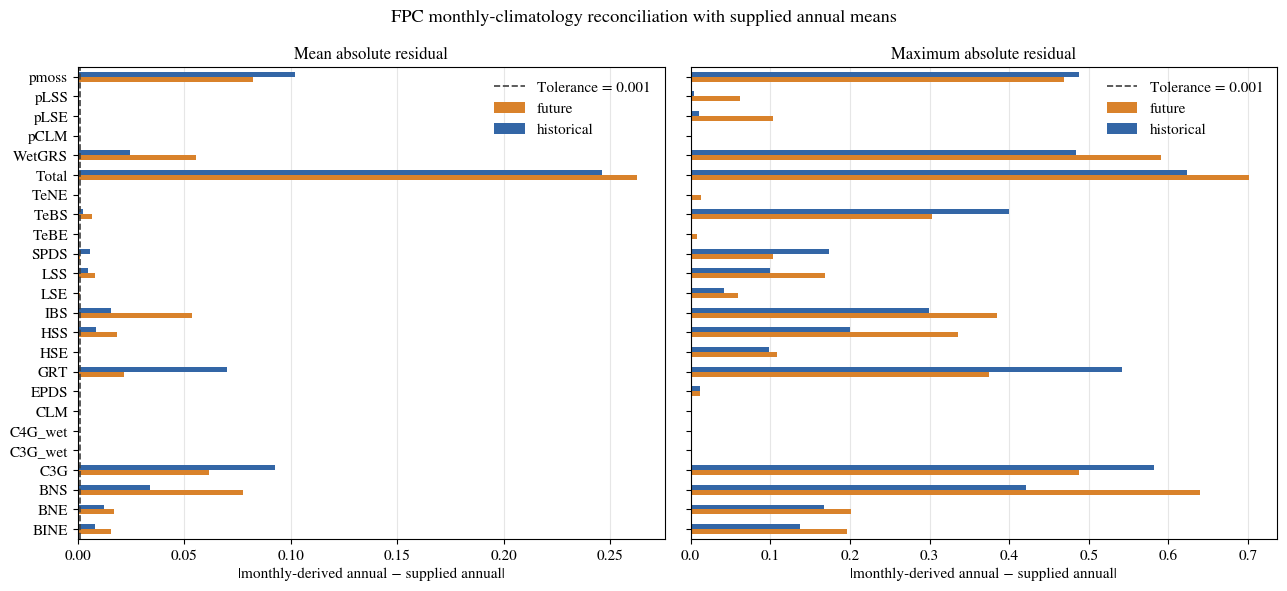

In [6]:
fpc_residuals = annual_reconciliation.loc[annual_reconciliation["variable"].eq("FPC")].copy()
if not fpc_residuals.empty:
    mean_abs = fpc_residuals.pivot(index="field", columns="period", values="mean absolute residual")
    max_abs = fpc_residuals.pivot(index="field", columns="period", values="maximum absolute residual")

    fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
    mean_abs.plot.barh(ax=axes[0], color=["#3366A6" if col == "historical" else "#D9822B" for col in mean_abs.columns])
    max_abs.plot.barh(ax=axes[1], color=["#3366A6" if col == "historical" else "#D9822B" for col in max_abs.columns])
    axes[0].set(title="Mean absolute residual", xlabel="|monthly-derived annual − supplied annual|", ylabel="")
    axes[1].set(title="Maximum absolute residual", xlabel="|monthly-derived annual − supplied annual|", ylabel="")
    for ax in axes:
        ax.axvline(ANNUAL_TOLERANCE, color="0.25", linestyle="--", linewidth=1.2, label=f"Tolerance = {ANNUAL_TOLERANCE}")
        ax.grid(axis="x", color="0.9")
        ax.set_axisbelow(True)
        ax.legend(frameon=False)
    fig.suptitle("FPC monthly-climatology reconciliation with supplied annual means")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "monthly_mean_annual_reconciliation.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIGURE_DIR / "monthly_mean_annual_reconciliation.pdf", bbox_inches="tight")
    plt.show()

## 6 · Audit conclusion

In [7]:
raw_sequence_pass = bool(sequence_report["exact sequence valid"].all())
transformation_pass = bool(transformation_report["exact transformation check passed"].all())

annual_status = (
    annual_reconciliation.groupby(["variable", "period"])["maximum absolute residual"]
    .max().rename("maximum absolute residual").to_frame()
)
annual_status["all fields within tolerance"] = annual_status["maximum absolute residual"].le(ANNUAL_TOLERANCE)

conclusion = pd.Series({
    "raw historical sequences valid": raw_sequence_pass,
    "generated historical monthly means reproduce independent calculation": transformation_pass,
    "generated-value tolerance": GENERATED_TOLERANCE,
    "annual-reconciliation tolerance": ANNUAL_TOLERANCE,
}, name="result")

display(conclusion.to_frame())
display(annual_status)

if raw_sequence_pass and transformation_pass:
    print("PASS: the historical monthly climatologies were correctly calculated from the original series.")
else:
    print("FAIL: inspect the raw-sequence and transformation residual tables before using the climatologies.")

print(
    "Annual reconciliation is a separate consistency check. A failure there does not by itself mean the "
    "historical monthly mean was calculated incorrectly; it may reveal different annual weighting, period "
    "definitions, rounding, or upstream processing."
)

,result
raw historical sequences valid,True
generated historical monthly means reproduce independent calculation,True
generated-value tolerance,0.000001
annual-reconciliation tolerance,0.001


maximum absolute residual  all fields within tolerance
variable period                                                            
FPC      future                       0.701242                        False
         historical                   0.623622                        False
LAI      future                       2.749661                        False
         historical                   2.372962                        False

PASS: the historical monthly climatologies were correctly calculated from the original series.
Annual reconciliation is a separate consistency check. A failure there does not by itself mean the historical monthly mean was calculated incorrectly; it may reveal different annual weighting, period definitions, rounding, or upstream processing.


# Conclusions

### The results strongly support that the historical monthly climatologies were produced correctly.
Both original historical files contained 6,017,040 records, corresponding to 16,714 grid cells,
30 years, and 12 calendar months per year. Every grid-cell/month mean was
therefore calculated from exactly 30 observations.

The independently calculated climatologies reproduced the generated FPC and LAI historical monthly-mean files:
- maximum residual: $3.33\times10^{-7}$
- values outside tolerance: 0
- all 24 variables pass

That residual is exactly consistent with writing the climatologies to six decimal places. **Therefore, the Bash calculation was correct.**

### The disagreement is instead between the monthly and “annual” products.

The supplied “annual mean” files are not numerically equivalent to the mean of the 12 monthly climatological values:

| Variable |	Period	| Maximum discrepancy |
| --- | --- | --- |
| FPC	| historical	| 0.624 |
| FPC	| future	| 0.701 |
| LAI	| historical	| 2.373 |
| LAI	| future	| 2.750 |

These differences are much too large to be caused by numerical rounding or calendar-month weighting.

For example, future total LAI derived from the monthly data is, on average, approximately 1.04 lower than the supplied annual LAI. This suggests that the annual products may represent a peak-growing-season value, an end-of-year state, or another LPJ-GUESS diagnostic—not a calendar-year mean. **This should be confirmed with the data producer or the output-generation code.**

Consequently, **I would not label fpc1971to2000.txt and the corresponding future file as “annual mean”** without further evidence.

### Grid coverage
- Annual/reference grid: 16,750 cells
- Historical monthly grid: 16,714 cells — 36 absent, or 0.21%
- Future monthly grid: 16,619 cells — 131 absent, or 0.78%
- Monthly-only cells: 0

The monthly products are subsets of the annual grid. 

**Historical–future comparisons are
therefore restricted to the 16,619 grid cells represented in both monthly
datasets.**